In [1]:
from transformers import AutoTokenizer

prompt = "It was a dark and stormy"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
input_ids = tokenizer(prompt)["input_ids"]
print(input_ids)

c:\Conda\envs\Handsongenai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Conda\envs\Handsongenai\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Deep work\.cache\huggingface\hub\models--Qwen--Qwen2-0.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this

[2132, 572, 264, 6319, 323, 13458, 88]


In [2]:
for token in input_ids:
    print(token, "\t:", tokenizer.decode(token))

2132 	: It
572 	:  was
264 	:  a
6319 	:  dark
323 	:  and
13458 	:  storm
88 	: y


In [3]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [4]:
input_ids = tokenizer(prompt,return_tensors="pt")["input_ids"]

outputs = model(input_ids)


In [5]:
print(outputs.logits.shape)

final_logits = outputs.logits[0,-1]

torch.Size([1, 7, 151936])


In [6]:
tokenizer.decode(final_logits.argmax())

' night'

In [7]:
import torch

top10_logits = torch.topk(final_logits,10)

for index in top10_logits.indices:
    print(tokenizer.decode(index))

 night
 evening
 day
 morning
 winter
 afternoon
 Saturday
 Sunday
 Friday
 October


In [8]:
top10 = torch.topk(final_logits.softmax(dim=0),10)

for value,index in zip(top10.values,top10_logits.indices):
    print(tokenizer.decode(index),value.item())

 night 0.8870638608932495
 evening 0.043002158403396606
 day 0.02191707119345665
 morning 0.004866056144237518
 winter 0.004494061693549156
 afternoon 0.0027222116477787495
 Saturday 0.00251726433634758
 Sunday 0.0018722177483141422
 Friday 0.0017145767342299223
 October 0.0016489929985255003


In [9]:
output_ids = model.generate(input_ids, max_new_tokens = 100)
decoded_text = tokenizer.decode(output_ids[0]) #Greedy decoding

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


In [10]:
print(decoded_text)

It was a dark and stormy night. The sky was dark and the wind was howling. The rain was pouring down and the lightning was flashing. The sky was dark and the wind was howling. The rain was pouring down and the lightning was flashing. The sky was dark and the wind was howling. The rain was pouring down and the lightning was flashing. The sky was dark and the wind was howling. The rain was pouring down and the lightning was flashing. The sky was dark and the wind was howling


In [11]:
beam_output = model.generate( 
    input_ids,
    max_new_tokens = 30,
    num_beams=5
) #Beam decoding


decoded_text = tokenizer.decode(beam_output[0]) #Greedy decoding

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


In [12]:
print(decoded_text)

It was a dark and stormy night. The wind was howling, and the rain was pouring down. The sky was dark and gloomy, and the air was filled with the


In [13]:
beam_output = model.generate( 
    input_ids,
    max_new_tokens = 1000,
    num_beams=5,
    repetition_penalty = 2.0
) #Beam decoding


decoded_text = tokenizer.decode(beam_output[0]) 

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


In [14]:
print(decoded_text)

It was a dark and stormy night. The sky was filled with thunder and lightning, and the wind howled in the distance. It was raining cats and dogs, and the streets were covered in puddles of water.

As I walked down the street, I noticed a group of children playing in the rain. They were laughing and having fun, but I couldn't help but feel a sense of unease creeping up on me.

Suddenly, I heard a loud noise coming from behind me. I turned around to see a man with a gun pointing his weapon at me. My heart raced as I realized what was happening.

"What are you doing out here?" he asked, his voice low and menacing.

"I don't know what you're talking about," I said, trying to keep my voice steady. "I'm just walking down the street."

The man raised his gun and pointed it at me again. "You'll pay for what you've done," he said, his voice dripping with venom.

I took a deep breath and tried to remain calm. "I didn't do anything wrong," I said. "I was just walking down the street."

The man sh

In [15]:
output_sample = model.generate( 
    input_ids,
    max_new_tokens = 38,
    do_sample=True,
    top_k = 0
) 
decoded_text = tokenizer.decode(output_sample[0]) 
print(decoded_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night and we were looking for our room, but it was impossible. The door was open and two girls were spying into the window. “Who are they?” the woman asked and we said


In [16]:
output_sample = model.generate( 
    input_ids,
    max_new_tokens = 100,
    do_sample=True,
    top_k = 0,
    temperature = 1
) 
decoded_text = tokenizer.decode(output_sample[0]) 
print(decoded_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It was a dark and stormy night in 1816. The passing of the Kentucky Lord Edward Morgan and the death of his Lieutenant Harry Boyd occurred soon after jilted lovers Anne Sobieck and Marth Clark set watchtowers on one another to ensure the safest way in which to be safely separated from each other.
Sometimes the result is bitter. Sometimes it's even rarer, and that sadly isn't always what happens. When legislators request assistance from local governments, they are often unwilling to let the problems commission


In [17]:
tokenizer.encode(" positive"),tokenizer.encode(" negative")


def score(review):
    prompt = f"""Question: Is the following review positive or negative about the movie? 
    Review: {review} Answer:"""

    input_ids = tokenizer(prompt,return_tensors="pt").input_ids
    final_logits = model(input_ids).logits[0,-1][[6785,8225]]
    if final_logits[0] > final_logits[1]:
        print("Positive")
        print(final_logits.softmax(dim=0))
    else:
        print("Negative")
        print(final_logits.softmax(dim=0))
    

In [18]:
score("This movie is the bomb!")

score("This movie bombed")

score("This movie blew me away with how good the ending was")

Positive
tensor([0.5675, 0.4325], grad_fn=<SoftmaxBackward0>)
Negative
tensor([0.2045, 0.7955], grad_fn=<SoftmaxBackward0>)
Negative
tensor([0.2962, 0.7038], grad_fn=<SoftmaxBackward0>)


In [19]:

def translate(sentence):
    prompt = f"""\
    Translate English to Spanish:

    English: I dont not speak Spanish.
    Spanish: No hablo español.

    English: {sentence}
    Spanish:
    """

    inputs = tokenizer(prompt,return_tensors="pt").input_ids
    output = model.generate(inputs,
                            max_new_tokens = 15
                            )
    
    return tokenizer.decode(output[0])


In [20]:
print(translate("I like football"))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


    Translate English to Spanish:

    English: I dont not speak Spanish.
    Spanish: No hablo español.

    English: I like football
    Spanish:
     "Me gusta el fútbol"

    English: I like to


In [21]:
from transformers import pipeline

fill_masker = pipeline("fill-mask", model="bert-base-uncased")
fill_masker("The [MASK] is made of milk.")

c:\Conda\envs\Handsongenai\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Deep work\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. F

[{'score': 0.19546672701835632,
  'token': 9841,
  'token_str': 'dish',
  'sequence': 'the dish is made of milk.'},
 {'score': 0.1290750503540039,
  'token': 8808,
  'token_str': 'cheese',
  'sequence': 'the cheese is made of milk.'},
 {'score': 0.1059066578745842,
  'token': 6501,
  'token_str': 'milk',
  'sequence': 'the milk is made of milk.'},
 {'score': 0.04112076386809349,
  'token': 4392,
  'token_str': 'drink',
  'sequence': 'the drink is made of milk.'},
 {'score': 0.037123341113328934,
  'token': 7852,
  'token_str': 'bread',
  'sequence': 'the bread is made of milk.'}]

In [22]:
classifier = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis")
classifier("This movie blew me away with how good it was")

c:\Conda\envs\Handsongenai\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Deep work\.cache\huggingface\hub\models--tabularisai--multilingual-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back 

[{'label': 'Positive', 'score': 0.5673620700836182}]

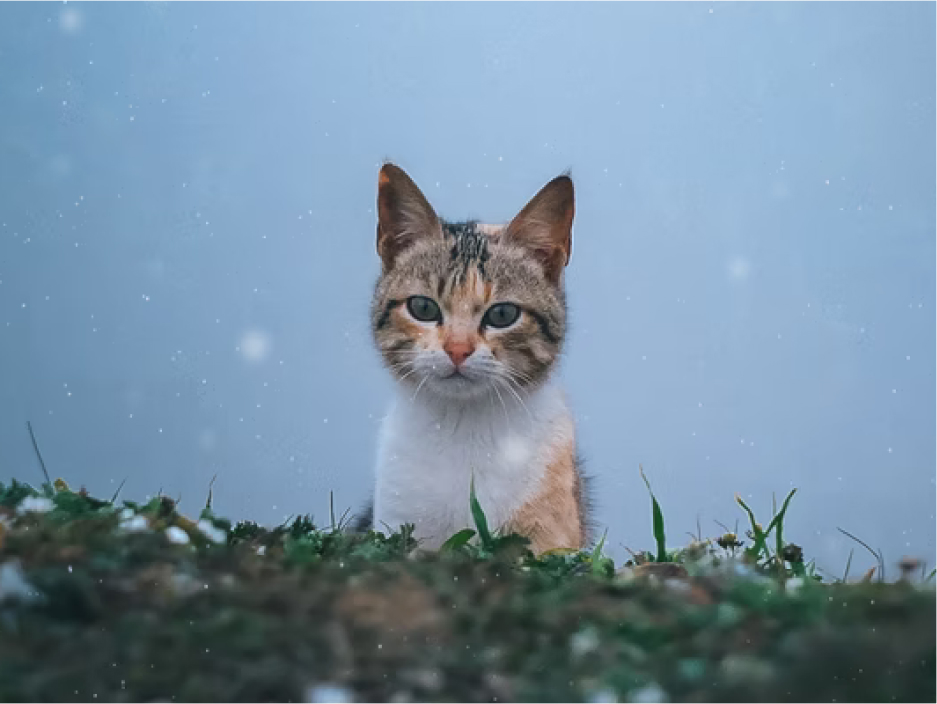

In [24]:
import requests
from PIL import Image

from genaibook.core import SampleURL


url = SampleURL.CatExample

image = Image.open(requests.get(url,stream=True).raw)
image

In [25]:
from transformers import pipeline
pipe = pipeline(
    "zero-shot-image-classification",
    model="openai/clip-vit-base-patch32"


)


labels = ["cat","dog","zebra","feline"]


c:\Conda\envs\Handsongenai\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Deep work\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP

[{'score': 0.5242406725883484, 'label': 'feline'}, {'score': 0.4727473855018616, 'label': 'cat'}, {'score': 0.0028746980242431164, 'label': 'dog'}, {'score': 0.00013720159768126905, 'label': 'zebra'}]


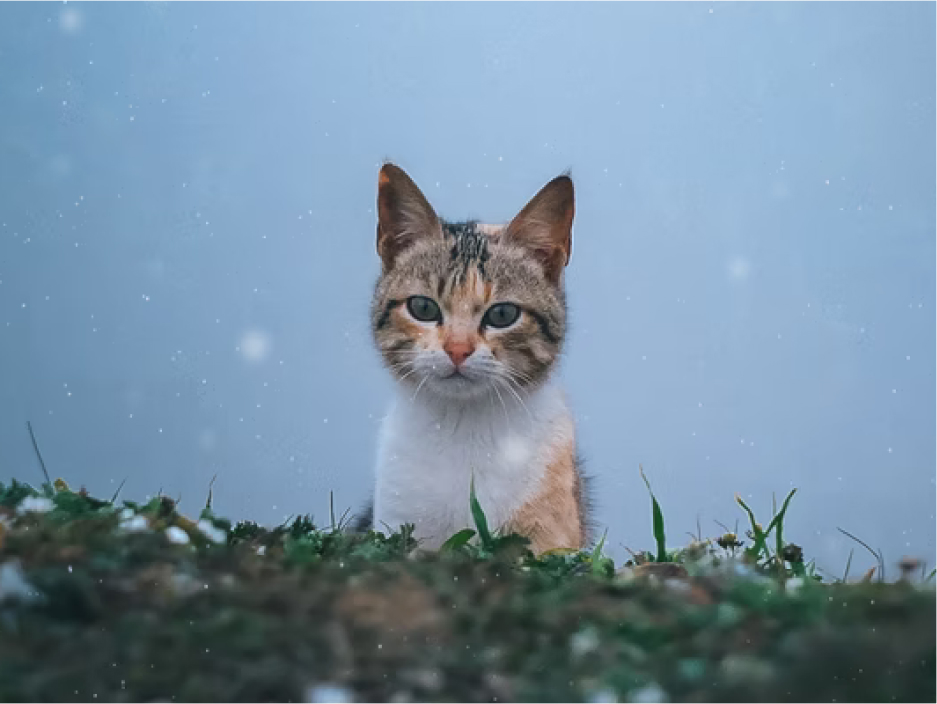

In [27]:
print(pipe(image,candidate_labels=labels))
image